# Exercise 8.2 — Market Share Competition and Bifurcation Analysis

## Problem Setup

Two companies A and B compete for local market share. Let $x$ = market share of A, $y$ = market share of B. Since there are no third-party competitors:

$$x + y = 1 \implies y = 1 - x$$

So the relative competitive edge $x - y$ simplifies to:

$$x - y = x - (1 - x) = 2x - 1$$

The model for A's market share is:

$$\frac{dx}{dt} = ax(1-x)(x-y) = ax(1-x)(2x-1) \qquad (8.18)$$

## Part 1: Equilibria and Stability of Equation (8.18)

### Finding Equilibria

Set $\frac{dx}{dt} = 0$:

$$ax(1-x)(2x-1) = 0$$

Each factor gives one equilibrium:

$$x^* = 0, \qquad x^* = \frac{1}{2}, \qquad x^* = 1$$

### Stability Analysis

Compute $f'(x)$ where $f(x) = ax(1-x)(2x-1)$. Using the product rule:

$$f'(x) = a\left[(1-x)(2x-1) + x(-1)(2x-1) + x(1-x)(2)\right]$$

$$= a\left[(2x-1)(1-x-x) + 2x(1-x)\right] = a\left[-(2x-1)^2 + 2x(1-x)\right]$$

Evaluating at each equilibrium (assuming $a > 0$):

| Equilibrium | $f'(x^*)$ | Stability |
|:-----------:|:---------:|:---------:|
| $x^* = 0$ | $a[-(−1)^2 + 0] = -a < 0$ | **Stable** |
| $x^* = \frac{1}{2}$ | $a[0 + 2(\frac{1}{2})(\frac{1}{2})] = \frac{a}{2} > 0$ | **Unstable** |
| $x^* = 1$ | $a[-(1)^2 + 0] = -a < 0$ | **Stable** |

### Interpretation

For $a > 0$ this is a classic **winner-take-all** dynamic:
- $x^* = 0$: Company B captures 100% of the market (stable)
- $x^* = 1$: Company A captures 100% of the market (stable)
- $x^* = \frac{1}{2}$: Equal split — an **unstable tipping point** (repeller)

Whichever company holds more than 50% market share tends toward complete dominance. The boundary $x = \frac{1}{2}$ is the separatrix between the two basins of attraction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

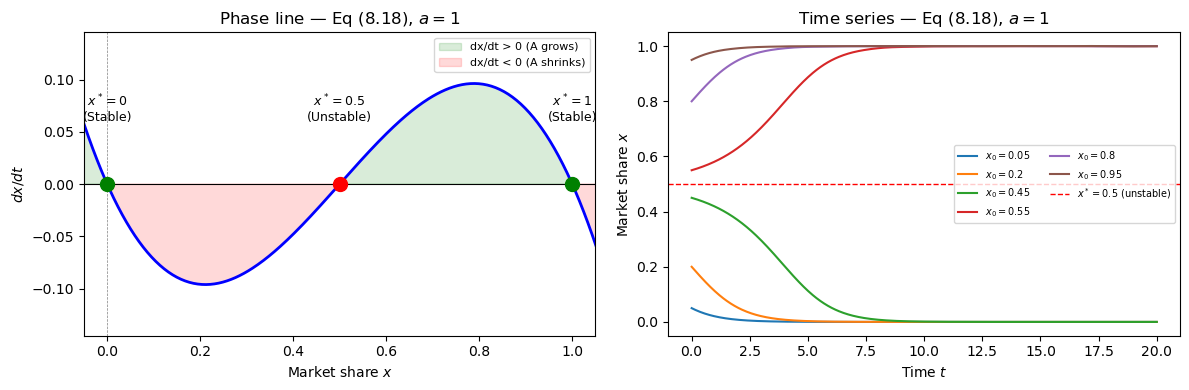

In [2]:
# --- Phase portrait for Eq 8.18 ---
a = 1.0

def f_818(x, a=1.0):
    return a * x * (1 - x) * (2*x - 1)

x_vals = np.linspace(-0.1, 1.1, 400)
dxdt = f_818(x_vals, a)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: dx/dt vs x (1D phase line)
ax = axes[0]
ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.plot(x_vals, dxdt, 'b', lw=2)
ax.fill_between(x_vals, 0, dxdt, where=dxdt > 0, alpha=0.15, color='green', label='dx/dt > 0 (A grows)')
ax.fill_between(x_vals, 0, dxdt, where=dxdt < 0, alpha=0.15, color='red', label='dx/dt < 0 (A shrinks)')
# Mark equilibria
for xeq, stab, col in [(0, 'Stable', 'green'), (0.5, 'Unstable', 'red'), (1, 'Stable', 'green')]:
    ax.plot(xeq, 0, 'o', ms=10, color=col, zorder=5)
    ax.annotate(f'$x^*={xeq}$\n({stab})', xy=(xeq, 0), xytext=(xeq, 0.06),
                ha='center', fontsize=9)
ax.set_xlim(-0.05, 1.05)
ax.set_xlabel('Market share $x$')
ax.set_ylabel('$dx/dt$')
ax.set_title('Phase line — Eq (8.18), $a=1$')
ax.legend(fontsize=8)

# Right: time series from various initial conditions
ax2 = axes[1]
t_span = (0, 20)
t_eval = np.linspace(0, 20, 500)
for x0 in [0.05, 0.2, 0.45, 0.55, 0.8, 0.95]:
    sol = solve_ivp(lambda t, y: [f_818(y[0], a)], t_span, [x0], t_eval=t_eval, dense_output=True)
    lbl = f'$x_0={x0}$'
    ax2.plot(sol.t, sol.y[0], label=lbl)
ax2.axhline(0.5, color='r', ls='--', lw=1, label='$x^*=0.5$ (unstable)')
ax2.set_xlabel('Time $t$')
ax2.set_ylabel('Market share $x$')
ax2.set_title('Time series — Eq (8.18), $a=1$')
ax2.legend(fontsize=7, ncol=2)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## Part 2: Global Market Influence — Bifurcation Analysis of Equation (8.19)

Now add the global market term:

$$\frac{dx}{dt} = ax(1-x)(2x-1) + r(p - x) \qquad (8.19)$$

where $r > 0$ is the global influence strength and $p$ is A's global market share (held constant).

### Finding the Critical Condition (Bifurcation Point)

**Step 1 — Check $x^* = p = \frac{1}{2}$ for all $r$.**

With $p = \frac{1}{2}$, substituting $x = \frac{1}{2}$ into (8.19):

$$a \cdot \frac{1}{2} \cdot \frac{1}{2} \cdot 0 + r\left(\frac{1}{2} - \frac{1}{2}\right) = 0 \checkmark$$

So $x^* = \frac{1}{2}$ is an equilibrium **for all values of $r$**.

**Step 2 — Stability of $x^* = \frac{1}{2}$.**

Let $g(x) = ax(1-x)(2x-1) + r(p-x)$. Then:

$$g'(x) = a\left[-(2x-1)^2 + 2x(1-x)\right] - r$$

At $x^* = \frac{1}{2}$:

$$g'\!\left(\tfrac{1}{2}\right) = a\left[0 + 2 \cdot \tfrac{1}{2} \cdot \tfrac{1}{2}\right] - r = \frac{a}{2} - r$$

This changes sign at:

$$\boxed{r_c = \frac{a}{2}}$$

| Condition | Stability of $x^* = \frac{1}{2}$ |
|:---------:|:---------------------------------:|
| $r < r_c$ | Unstable (tipping point survives) |
| $r = r_c$ | Bifurcation point |
| $r > r_c$ | Stable (global market takes over) |

**Step 3 — Local normal form (confirms pitchfork structure).**

Let $u = x - \frac{1}{2}$ (shift equilibrium to origin). Expanding $g(u + \frac{1}{2})$ to third order:

$$g \approx \left(\frac{a}{2} - r\right)u - 2au^3$$

This is the standard **supercritical pitchfork** normal form $\dot{u} = \mu u - cu^3$ with $\mu = \frac{a}{2} - r$ and $c = 2a > 0$.

- For $r > r_c$: $\mu < 0$ — only $u = 0$ ($x = \frac{1}{2}$) is stable.
- For $r < r_c$: $\mu > 0$ — $x = \frac{1}{2}$ becomes unstable, and two stable branches emerge at $x^* = \frac{1}{2} \pm \sqrt{\frac{\mu}{2a}}$.

### With $a = 1$, $p = 0.5$: Critical threshold is $r_c = 0.5$.

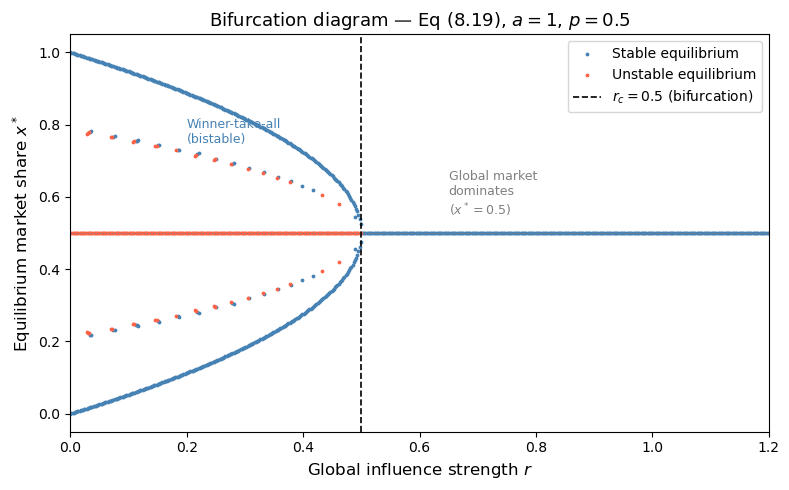

Critical threshold: r_c = a/2 = 0.5


In [3]:
# --- Bifurcation diagram for Eq 8.19 with a=1, p=0.5 ---
from scipy.optimize import fsolve

a_val = 1.0
p_val = 0.5

def g_819(x, r, a=1.0, p=0.5):
    return a * x * (1 - x) * (2*x - 1) + r * (p - x)

def g_prime(x, r, a=1.0):
    return a * (-(2*x - 1)**2 + 2*x*(1 - x)) - r

r_vals = np.linspace(0, 1.2, 600)
r_c = a_val / 2  # = 0.5

# Collect equilibria numerically for each r
eq_stable   = []
eq_unstable = []

x_test = np.linspace(0.01, 0.99, 80)

for r in r_vals:
    found = set()
    for x0 in x_test:
        try:
            sol = fsolve(g_819, x0, args=(r,), full_output=True)
            xeq = sol[0][0]
            if 0 <= xeq <= 1:
                xeq_rounded = round(xeq, 6)
                if xeq_rounded not in found:
                    found.add(xeq_rounded)
                    if g_prime(xeq, r) < 0:
                        eq_stable.append((r, xeq))
                    else:
                        eq_unstable.append((r, xeq))
        except:
            pass

r_s, x_s = zip(*eq_stable)   if eq_stable   else ([], [])
r_u, x_u = zip(*eq_unstable) if eq_unstable else ([], [])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(r_s, x_s, s=3, color='steelblue', label='Stable equilibrium')
ax.scatter(r_u, x_u, s=3, color='tomato',    label='Unstable equilibrium')
ax.axvline(r_c, color='k', ls='--', lw=1.2, label=f'$r_c = {r_c}$ (bifurcation)')
ax.axhline(0.5, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Global influence strength $r$', fontsize=12)
ax.set_ylabel("Equilibrium market share $x^*$", fontsize=12)
ax.set_title("Bifurcation diagram — Eq (8.19), $a=1$, $p=0.5$", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, 1.2)
ax.annotate('Winner-take-all\n(bistable)', xy=(0.2, 0.75), fontsize=9, color='steelblue')
ax.annotate('Global market\ndominates\n$(x^*=0.5)$', xy=(0.65, 0.55), fontsize=9, color='gray')
plt.tight_layout()
plt.show()

print(f"Critical threshold: r_c = a/2 = {r_c}")

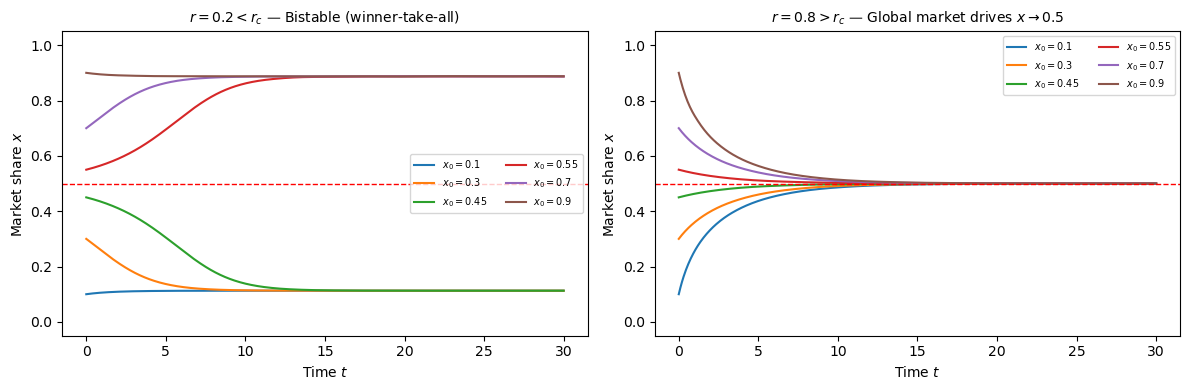

In [4]:
# --- Time series showing the regime shift on either side of r_c ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_span = (0, 30)
t_eval = np.linspace(0, 30, 600)
x0_vals = [0.1, 0.3, 0.45, 0.55, 0.7, 0.9]

for r_plot, ax, title in [(0.2, axes[0], '$r=0.2 < r_c$ — Bistable (winner-take-all)'),
                           (0.8, axes[1], '$r=0.8 > r_c$ — Global market drives $x \\to 0.5$')]:
    for x0 in x0_vals:
        sol = solve_ivp(lambda t, y: [g_819(y[0], r_plot)], t_span, [x0], t_eval=t_eval)
        ax.plot(sol.t, sol.y[0], label=f'$x_0={x0}$')
    ax.axhline(0.5, color='r', ls='--', lw=1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Time $t$')
    ax.set_ylabel('Market share $x$')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

### Summary: Bifurcation Type

This is a **supercritical pitchfork bifurcation** at $r_c = \frac{a}{2}$.

- For $r > r_c$: the global market erases the winner-take-all dynamic. The single stable equilibrium $x^* = \frac{1}{2}$ means market share is pinned to the global value $p$.
- For $r < r_c$: the global influence is too weak to overcome local competitive dynamics. $x^* = \frac{1}{2}$ becomes an unstable tipping point, and two stable equilibria emerge — one near 0 (B wins locally) and one near 1 (A wins locally).
- The bifurcation represents a **transition between market regimes**: from a globally-coupled equilibrium market to a bistable winner-take-all market.

## Part 3: Marketing Strategy — How to "Flip" the Market

### Setup

Suppose company A is currently being overwhelmed — its local market share $x$ is small and stuck near $x^* = 0$ (B dominates). The bifurcation analysis tells us exactly what levers are available.

---

### Strategy 1: Cross the Tipping Point (Brute-Force Push)

When $r < r_c$, the unstable equilibrium $x^* = \frac{1}{2}$ acts as a threshold. If A can push its local market share **above 50%** through any means — heavy advertising, promotions, temporary discounts, strategic partnerships — the dynamics take over. Once $x > \frac{1}{2}$, the term $x - y = 2x - 1 > 0$ becomes positive and self-reinforcing, driving A toward full market dominance $x \to 1$.

This is high-risk but potentially decisive. Think of it as the "blitz" strategy.

---

### Strategy 2: Win Globally First, Then Let It Trickle Down ($r > r_c$)

This is the smarter play. Rather than fighting the local winner-take-all dynamic directly, company A should:

1. **Establish a strong position in the broader national or global market**, pushing $p > \frac{1}{2}$.
2. **Strengthen the coupling** $r$ between global and local markets (e.g., through brand recognition, media presence, supply-chain integration).

Once $r > r_c = a/2$, the bifurcation disappears — the local winner-take-all dynamic is suppressed. The local market then converges to $p$ regardless of initial conditions. If $p > \frac{1}{2}$, the local market naturally follows. There's no longer a need to "fight" locally.

This is the strategy large multinational brands use: build global dominance, and local markets self-correct.

---

### Strategy 3: Reduce the Competitive Intensity ($a \downarrow$, raising $r_c$)

Lowering $a$ raises the threshold $r_c = a/2$, meaning the same global influence $r$ now exceeds $r_c$ more easily. A could:

- Differentiate its product to avoid direct head-to-head comparison.
- Target a different customer segment entirely (reducing the effective competition parameter $a$).
- Form a strategic alliance to reduce competitive intensity.

---

### Key Takeaway

The model reveals that the local market has a **bifurcation point** that separates two fundamentally different behaviors. A losing company cannot gradually "improve" its way to dominance if $r < r_c$ — it needs either a **sudden push past $x = \frac{1}{2}$** or a **regime change via global influence**. Incremental improvement while stuck below the tipping point will always revert back to near zero. The math recommends going big globally, or going home.